In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")


<div style="background: white; display: inline-block;"><img src="https://raw.githubusercontent.com/gmxavier/TEP-meets-LSTM/master/tep_flowsheet.png" width="900" height="900""/></div>

Parameter | Value
----------|----------
Associated Tasks | Anomaly Detection, Classification
Data Source | Synthetic
Dataset Characteristics | Multivariate, Time-Series, Synthetic
Date Donated | Information not available
Feature Type | Real
Labeled | Yes
Missing Values | No
Name | Tennessee Eastman Process Simulation Dataset
Number of Features | Information not available
Number of Instances | Information not available
Source | Harvard Dataverse
Time Series | Yes

### Manipulated Variables

Variable | Description
-------- | -----------
`XMV(1)`  | D Feed Flow (stream 2)            (Corrected Order)
`XMV(2)`  | E Feed Flow (stream 3)            (Corrected Order)
`XMV(3)`  | A Feed Flow (stream 1)            (Corrected Order)
`XMV(4)`  | A and C Feed Flow (stream 4)
`XMV(5)`  | Compressor Recycle Valve
`XMV(6)`  | Purge Valve (stream 9)
`XMV(7)`  | Separator Pot Liquid Flow (stream 10)
`XMV(8)`  | Stripper Liquid Product Flow (stream 11)
`XMV(9)`  | Stripper Steam Valve
`XMV(10)` | Reactor Cooling Water Flow
`XMV(11)` | Condenser Cooling Water Flow
`XMV(12)` | Agitator Speed

### Continuous Process Measurements

Variable | Description | unit
-------- | ----------- | ----
`XMEAS(1)`  | A Feed  (stream 1)                  | kscmh
`XMEAS(2)`  | D Feed  (stream 2)                  | kg/hr
`XMEAS(3)`  | E Feed  (stream 3)                  | kg/hr
`XMEAS(4)`  | A and C Feed  (stream 4)            | kscmh
`XMEAS(5)`  | Recycle Flow  (stream 8)            | kscmh
`XMEAS(6)`  | Reactor Feed Rate  (stream 6)       | kscmh
`XMEAS(7)`  | Reactor Pressure                    | kPa gauge
`XMEAS(8)`  | Reactor Level                       | %
`XMEAS(9)`  | Reactor Temperature                 | Deg C
`XMEAS(10)` | Purge Rate (stream 9)               | kscmh
`XMEAS(11)` | Product Sep Temp                    | Deg C
`XMEAS(12)` | Product Sep Level                   | %
`XMEAS(13)` | Prod Sep Pressure                   | kPa gauge
`XMEAS(14)` | Prod Sep Underflow (stream 10)      | m3/hr
`XMEAS(15)` | Stripper Level                      | %
`XMEAS(16)` | Stripper Pressure                   | kPa gauge
`XMEAS(17)` | Stripper Underflow (stream 11)      | m3/hr
`XMEAS(18)` | Stripper Temperature                | Deg C
`XMEAS(19)` | Stripper Steam Flow                 | kg/hr
`XMEAS(20)` | Compressor Work                     | kW
`XMEAS(21)` | Reactor Cooling Water Outlet Temp   | Deg C
`XMEAS(22)` | Separator Cooling Water Outlet Temp | Deg C

### Sampled Process Measurements

- Reactor Feed Analysis (Stream 6)
  > - Sampling Frequency = 0.1 hr
  > - Dead Time = 0.1 hr
  > - Mole %
  
Variable | Description
-------- | -----------
`XMEAS(23)` | Component A
`XMEAS(24)` | Component B
`XMEAS(25)` | Component C
`XMEAS(26)` | Component D
`XMEAS(27)` | Component E
`XMEAS(28)` | Component F

- Purge Gas Analysis (Stream 9)
  > - Sampling Frequency = 0.1 hr
  > - Dead Time = 0.1 hr
  > - Mole %

Variable | Description
-------- | -----------
`XMEAS(29)` | Component A
`XMEAS(30)` | Component B
`XMEAS(31)` | Component C
`XMEAS(32)` | Component D
`XMEAS(33)` | Component E
`XMEAS(34)` | Component F
`XMEAS(35)` | Component G
`XMEAS(36)` | Component H

- Product Analysis (Stream 11)
  > - Sampling Frequency = 0.25 hr
  > - Dead Time = 0.25 hr
  > - Mole %

Variable | Description
-------- | -----------
`XMEAS(37)` | Component D
`XMEAS(38)` | Component E
`XMEAS(39)` | Component F
`XMEAS(40)` | Component G
`XMEAS(41)` | Component H

### Process Disturbances

Variable | Description
-------- | -----------
`IDV(1)`  | A/C Feed Ratio, B Composition Constant (Stream 4)          Step
`IDV(2)`  | B Composition, A/C Ratio Constant (Stream 4)               Step
`IDV(3)`  | D Feed Temperature (Stream 2)                              Step
`IDV(4)`  | Reactor Cooling Water Inlet Temperature                    Step
`IDV(5)`  | Condenser Cooling Water Inlet Temperature                  Step
`IDV(6)`  | A Feed Loss (Stream 1)                                     Step
`IDV(7)`  | C Header Pressure Loss - Reduced Availability (Stream 4)   Step
`IDV(8)`  | A, B, C Feed Composition (Stream 4)            Random Variation
`IDV(9)`  | D Feed Temperature (Stream 2)                  Random Variation
`IDV(10)` | C Feed Temperature (Stream 4)                  Random Variation
`IDV(11)` | Reactor Cooling Water Inlet Temperature        Random Variation
`IDV(12)` | Condenser Cooling Water Inlet Temperature      Random Variation
`IDV(13)` | Reaction Kinetics                                    Slow Drift
`IDV(14)` | Reactor Cooling Water Valve                            Sticking
`IDV(15)` | Condenser Cooling Water Valve                          Sticking
`IDV(16)` | Unknown
`IDV(17)` | Unknown
`IDV(18)` | Unknown
`IDV(19)` | Unknown
`IDV(20)` | Unknown

## EDA-Ziel

Die folgenden Zellen bringen den Datensatz in eine Form, die für AutoML in der Anomalieerkennung direkt nützlich ist:

1. Verfügbare Parquet-Dateien laden und Spalten vereinheitlichen.
2. Datenumfang, Fehlwerte und Klassenverteilung prüfen.
3. Zeitverläufe, Korrelationen und eine PCA-Projektion als erste Strukturkontrolle ansehen.
4. Den Unterschied zwischen Training-/Testdaten und FaultFree-/Faulty-Splits sauber beachten.


## Tennessee Eastman Process Dataset

Der Tennessee Eastman Process Datensatz ist ein synthetischer, multivariater Zeitreihendatensatz aus einer simulierten chemischen Anlage. Er enthält Prozessmessungen, Stellgrößen und verschiedene Fault-Szenarien und wird häufig als Benchmark für Anomalieerkennung und Prozessüberwachung verwendet.

Für die Auswertung sind vor allem diese Punkte wichtig:

- Die Daten sind zeitabhängig, daher sind nicht nur Einzelwerte, sondern auch Verläufe und Übergänge relevant.
- Messgrößen und Stellgrößen sind stark miteinander gekoppelt, deshalb sind Korrelationen oft informativer als einzelne Spaltenwerte.
- Fehlerklassen können ungleich verteilt sein, wodurch Accuracy allein schnell irreführend wird.
- Für AutoML sind Skalierung, saubere Run-Trennung und ein Blick auf stabile versus variable Signale besonders wichtig.
- Der Datensatz ist synthetisch, bildet aber typische Probleme industrieller Prozesse gut ab, etwa Drift, Sprünge und verzögerte Reaktionen.

Die folgenden Zellen geben zuerst einen Überblick über die geladenen Dateien, dann über Klassenverteilung, Signalzusammenhänge und schließlich über Zeitverläufe und eine PCA-Projektion.

## Training, Test und Fault-Splits

Die vier Parquet-Dateien bilden zwei Achsen ab:

- `Training` vs. `Testing`: getrennte Daten für Modellaufbau und spätere Evaluation.
- `FaultFree` vs. `Faulty`: Normalbetrieb ohne Fehler gegenüber Prozessläufen mit Faults.

Für das Training ist wichtig:

- Bei Anomalieerkennung wird ein Modell oft nur auf `FaultFree_Training` gelernt, damit es den Normalbetrieb sauber beschreibt.
- `FaultFree_Testing` prüft anschließend, ob normale Läufe weiterhin als normal erkannt werden.
- `Faulty_Testing` dient dazu, Fehlererkennung und Schwellenwerte zu bewerten.
- `Faulty_Training` kann für supervised Ansätze genutzt werden, ist aber für klassische Anomalieerkennung oft nicht die erste Wahl.
- Training und Test dürfen nicht vermischt werden, sonst entsteht Data Leakage und die Ergebnisse wirken besser als sie wirklich sind.

Praktisch heißt das: Für einen ersten AutoML-Workflow solltest du die Dateien nicht einfach zusammenwerfen, sondern den Einsatzzweck pro Split bewusst festlegen.

### Supervised Learning: Trainingsdaten zusammenführen

Für ein supervised Modell brauchst du einen gemeinsamen Trainingssatz innerhalb des Trainingssplits. Normalbetrieb und Fault-Daten werden dabei nicht mit dem Testsplit vermischt.

In [13]:
required_splits = [
    "fault_free_training",
    "faulty_training",
    "fault_free_testing",
    "faulty_testing",
]
missing_splits = [split for split in required_splits if split not in frames]

if missing_splits:
    print(f"Es fehlen folgende Datensplits: {missing_splits}")
else:
    def add_supervised_targets(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
        enriched = frame.copy()
        enriched["split_name"] = split_name
        enriched["is_fault"] = 0 if "fault_free" in split_name else 1
        if "faultnumber" in enriched.columns:
            enriched["fault_class"] = enriched["faultnumber"].fillna(0).astype(int)
        else:
            enriched["fault_class"] = enriched["is_fault"]
        return enriched

    supervised_train = pd.concat(
        [
            add_supervised_targets(frames["fault_free_training"], "fault_free_training"),
            add_supervised_targets(frames["faulty_training"], "faulty_training"),
        ],
        ignore_index=True,
    )
    supervised_test = pd.concat(
        [
            add_supervised_targets(frames["fault_free_testing"], "fault_free_testing"),
            add_supervised_targets(frames["faulty_testing"], "faulty_testing"),
        ],
        ignore_index=True,
    )

    feature_columns = [
        column for column in supervised_train.columns
        if column.startswith(("xmeas_", "xmv_"))
    ]

    X_train = supervised_train[feature_columns]
    y_train_binary = supervised_train["is_fault"]
    y_train_multiclass = supervised_train["fault_class"]

    X_test = supervised_test[feature_columns]
    y_test_binary = supervised_test["is_fault"]
    y_test_multiclass = supervised_test["fault_class"]

    display(
        pd.DataFrame(
            {
                "split": ["supervised_train", "supervised_test"],
                "rows": [len(supervised_train), len(supervised_test)],
                "features": [len(feature_columns), len(feature_columns)],
                "fault_rows": [int(supervised_train["is_fault"].sum()), int(supervised_test["is_fault"].sum())],
            }
        )
    )
    display(X_train.head())

    print("Für einen Random Forest kannst du z. B. y_train_binary für Fault-vs-Normal oder y_train_multiclass für konkrete Fault-Klassen verwenden.")

,split,rows,features,fault_rows
0,supervised_train,5250000,52,5000000
1,supervised_test,10080000,52,9600000


,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,74.863,120.41,0.33818,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,75.000,120.41,0.33620,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,74.771,120.42,0.33563,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,75.224,120.39,0.33553,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,75.388,120.39,0.32632,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


Für einen Random Forest kannst du z. B. y_train_binary für Fault-vs-Normal oder y_train_multiclass für konkrete Fault-Klassen verwenden.


## Datenvorbereitung je Lernparadigma

### 1. Klassische Anomalieerkennung / Unsupervised

Für ein rein unsupervised Verfahren trainierst du nur auf Normalbetrieb:

- `FaultFree_Training` als Fit-Daten
- optional `FaultFree_Testing` als Validierung für Schwellenwerte oder Modellselektion
- `Faulty_Testing` nur für die abschließende Bewertung

Wichtig ist, dass das Modell den Normalzustand lernt und Abweichungen später als Anomalie bewertet. Hier werden die Fault-Labels nicht zum Trainieren verwendet.

### 2. AutoEncoder / Semi-supervised

Bei einem AutoEncoder ist die typische Idee ebenfalls, nur den Normalbetrieb zu rekonstruieren:

- Training auf `FaultFree_Training`
- Validierung auf einem separaten Normalbetrieb-Split, zum Beispiel `FaultFree_Testing`
- Fehlererkennung über Rekonstruktionsfehler

Die Fault-Daten nutzt du dann erst zum Schwellenwert-Tuning oder für die finale Auswertung. Das Modell lernt also keine expliziten Fault-Klassen, sondern eine kompakte Normalrepräsentation.

### 3. Supervised Learning, zum Beispiel Random Forest

Wenn du ein Klassifikationsmodell trainierst, brauchst du explizite Labels:

- Merkmale aus `FaultFree_Training` und `Faulty_Training`
- Zielvariable als Normal-vs.-Fault oder als konkrete Fault-Klasse
- Test auf `FaultFree_Testing` und `Faulty_Testing`

Wichtig dabei:

- Splitte möglichst nach Runs, nicht zeilenweise zufällig, damit benachbarte Zeitpunkte nicht in Training und Test landen.
- Bei starker Klassenungleichverteilung helfen Class Weights, Oversampling oder geeignete Metriken wie F1, Recall oder ROC-AUC.
- Für viele Klassifikatoren ist es sinnvoll, aus den Zeitreihen vorab Features pro Fenster oder pro Run zu erzeugen, statt jede Zeile isoliert zu behandeln.

### Praktische Faustregel

- Nur Normalbetrieb lernen: unsupervised oder AutoEncoder.
- Faults sollen explizit erkannt werden: supervised.
- In allen Fällen: keine Mischung von Training und Test auf Zeilenebene, sondern Trennung nach Runs oder Zeitblöcken.

## 1. Datensatz laden

Diese Zelle lädt die verfügbaren Parquet-Dateien und vereinheitlicht die Spaltennamen auf Kleinbuchstaben. Das ist wichtig, weil der spätere Code dann unabhängig von der ursprünglichen Groß- und Kleinschreibung der Exportspalten funktioniert.

Wichtig für die Interpretation:
- `df` steht für den aktuell betrachteten Datensatz.
- Bevorzugt wird der Faulty-Testdatensatz, falls er vorhanden ist.
- Die Ausgabe unten zeigt, welche Dateien tatsächlich im Ordner `data/` gefunden wurden und gibt einen ersten Blick auf die Rohspalten.

In [9]:
DATA_DIR = Path("data")
DATASETS = {
    "fault_free_testing": DATA_DIR / "TEP_FaultFree_Testing.parquet",
    "fault_free_training": DATA_DIR / "TEP_FaultFree_Training.parquet",
    "faulty_testing": DATA_DIR / "TEP_Faulty_Testing.parquet",
    "faulty_training": DATA_DIR / "TEP_Faulty_Training.parquet",
}


def load_dataset(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame.columns = [str(column).strip().lower() for column in frame.columns]
    return frame


available_datasets = {name: path for name, path in DATASETS.items() if path.exists()}
if not available_datasets:
    raise FileNotFoundError(
        "Keine Parquet-Dateien im data-Ordner gefunden. Erwartet werden TEP_FaultFree_*.parquet und TEP_Faulty_*.parquet."
    )

frames = {name: load_dataset(path) for name, path in available_datasets.items()}
df = frames.get("faulty_testing", next(iter(frames.values())))

display(pd.DataFrame({"dataset": list(frames.keys()), "path": [str(path) for path in available_datasets.values()]}))
display(df)

,dataset,path
0,fault_free_testing,data\TEP_FaultFree_Testing.parquet
1,fault_free_training,data\TEP_FaultFree_Training.parquet
2,faulty_testing,data\TEP_Faulty_Testing.parquet
3,faulty_training,data\TEP_Faulty_Training.parquet


,faultnumber,simulationrun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,1,1.0,1,0.25171,3672.4,4466.3,9.5122,27.057,42.473,2705.6,...,54.494,24.527,59.710,22.357,40.149,40.074,47.955,47.300,42.100,15.345
1,1,1.0,2,0.25234,3642.2,4568.7,9.4145,26.999,42.586,2705.2,...,53.269,24.465,60.466,22.413,39.956,36.651,45.038,47.502,40.553,16.063
2,1,1.0,3,0.24840,3643.1,4507.5,9.2901,26.927,42.278,2703.5,...,54.000,24.860,60.642,22.199,40.074,41.868,44.553,47.479,41.341,20.452
3,1,1.0,4,0.25153,3628.3,4519.3,9.3347,26.999,42.330,2703.9,...,53.860,24.553,61.908,21.981,40.141,40.066,48.048,47.440,40.780,17.123
4,1,1.0,5,0.21763,3655.8,4571.0,9.3087,26.901,42.402,2707.7,...,53.307,21.775,61.891,22.412,37.696,38.295,44.678,47.530,41.089,18.681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9599995,20,500.0,956,0.26494,3719.6,4536.7,9.2265,26.875,42.401,2708.3,...,54.382,26.018,62.068,20.708,37.589,35.121,45.496,42.653,40.816,15.846
9599996,20,500.0,957,0.25252,3724.0,4494.3,9.1873,27.221,41.999,2706.0,...,54.236,25.098,61.557,20.655,40.934,38.391,43.699,42.832,41.853,18.486
9599997,20,500.0,958,0.25164,3700.8,4537.3,9.2514,26.659,42.180,2704.7,...,53.722,25.185,61.169,20.650,40.694,35.961,45.643,43.147,40.538,18.127
9599998,20,500.0,959,0.29097,3641.8,4525.2,9.3053,26.823,42.234,2705.0,...,54.185,28.771,61.140,20.323,39.774,39.807,45.989,43.318,40.826,17.305


## 2. Dataset-Überblick

Diese Ausgabe fasst die wichtigsten Strukturmerkmale der geladenen Dateien zusammen:

- `rows`: Anzahl der Zeilen bzw. Zeitpunkte
- `columns`: Anzahl der Spalten
- `numeric_columns`: wie viele Spalten numerisch sind
- `missing_values`: Anzahl fehlender Werte
- `duplicate_rows`: doppelte Zeilen

Für AutoML in der Anomalieerkennung ist das relevant, weil du damit siehst, ob die Daten vollständig sind, ob mehrere Runs zusammengeführt wurden und wie stark das Schema zwischen den Dateien schwankt.

In [12]:
dataset_overview = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": frame.shape[0],
            "columns": frame.shape[1],
            "numeric_columns": int(frame.select_dtypes(include="number").shape[1]),
            "missing_values": int(frame.isna().sum().sum()),
            "duplicate_rows": int(frame.duplicated().sum()),
        }
        for name, frame in frames.items()
    ]
).sort_values("dataset")

display(dataset_overview)

column_preview = pd.DataFrame(
    {name: pd.Series(frame.columns) for name, frame in frames.items()}
)
display(column_preview)

,dataset,rows,columns,numeric_columns,missing_values,duplicate_rows
0,fault_free_testing,480000,55,55,0,0
1,fault_free_training,250000,55,55,0,0
2,faulty_testing,9600000,55,55,0,0
3,faulty_training,5000000,55,55,0,0


,fault_free_testing,fault_free_training,faulty_testing,faulty_training
0,faultnumber,faultnumber,faultnumber,faultnumber
1,simulationrun,simulationrun,simulationrun,simulationrun
2,sample,sample,sample,sample
3,xmeas_1,xmeas_1,xmeas_1,xmeas_1
4,xmeas_2,xmeas_2,xmeas_2,xmeas_2
5,xmeas_3,xmeas_3,xmeas_3,xmeas_3
6,xmeas_4,xmeas_4,xmeas_4,xmeas_4
7,xmeas_5,xmeas_5,xmeas_5,xmeas_5
8,xmeas_6,xmeas_6,xmeas_6,xmeas_6
9,xmeas_7,xmeas_7,xmeas_7,xmeas_7


## 3. Fault-Verteilung

Die Balkengrafik zeigt, wie sich die Zielklassen im ausgewählten Datensatz verteilen. Wenn eine Fault-Klasse deutlich häufiger vorkommt als andere, ist das ein Hinweis auf Klassenungleichgewicht.

Für die Modellierung ist das relevant, weil ein AutoML-System sonst dazu neigt, die Mehrheitsklasse zu bevorzugen. Dann wirkt die reine Accuracy oft besser, als das Modell in der Anomalieerkennung tatsächlich ist.

In [5]:
label_column = next((column for column in ("faultnumber", "fault_id", "label") if column in df.columns), None)

if label_column is None:
    print("Keine Zielspalte für Fault-Klassen gefunden.")
else:
    fault_counts = df[label_column].value_counts(dropna=False).sort_index()
    fault_summary = fault_counts.rename_axis(label_column).reset_index(name="rows")
    display(fault_summary)

    fig = px.bar(
        fault_summary,
        x=label_column,
        y="rows",
        title="Verteilung der Fault-Klassen",
        labels={label_column: label_column, "rows": "rows"},
    )
    fig.show()

,faultnumber,rows
0,1,480000
1,2,480000
2,3,480000
3,4,480000
4,5,480000
5,6,480000
6,7,480000
7,8,480000
8,9,480000
9,10,480000


,group,columns
0,Messungen,41
1,Stellgrößen,11
2,Gesamt,52


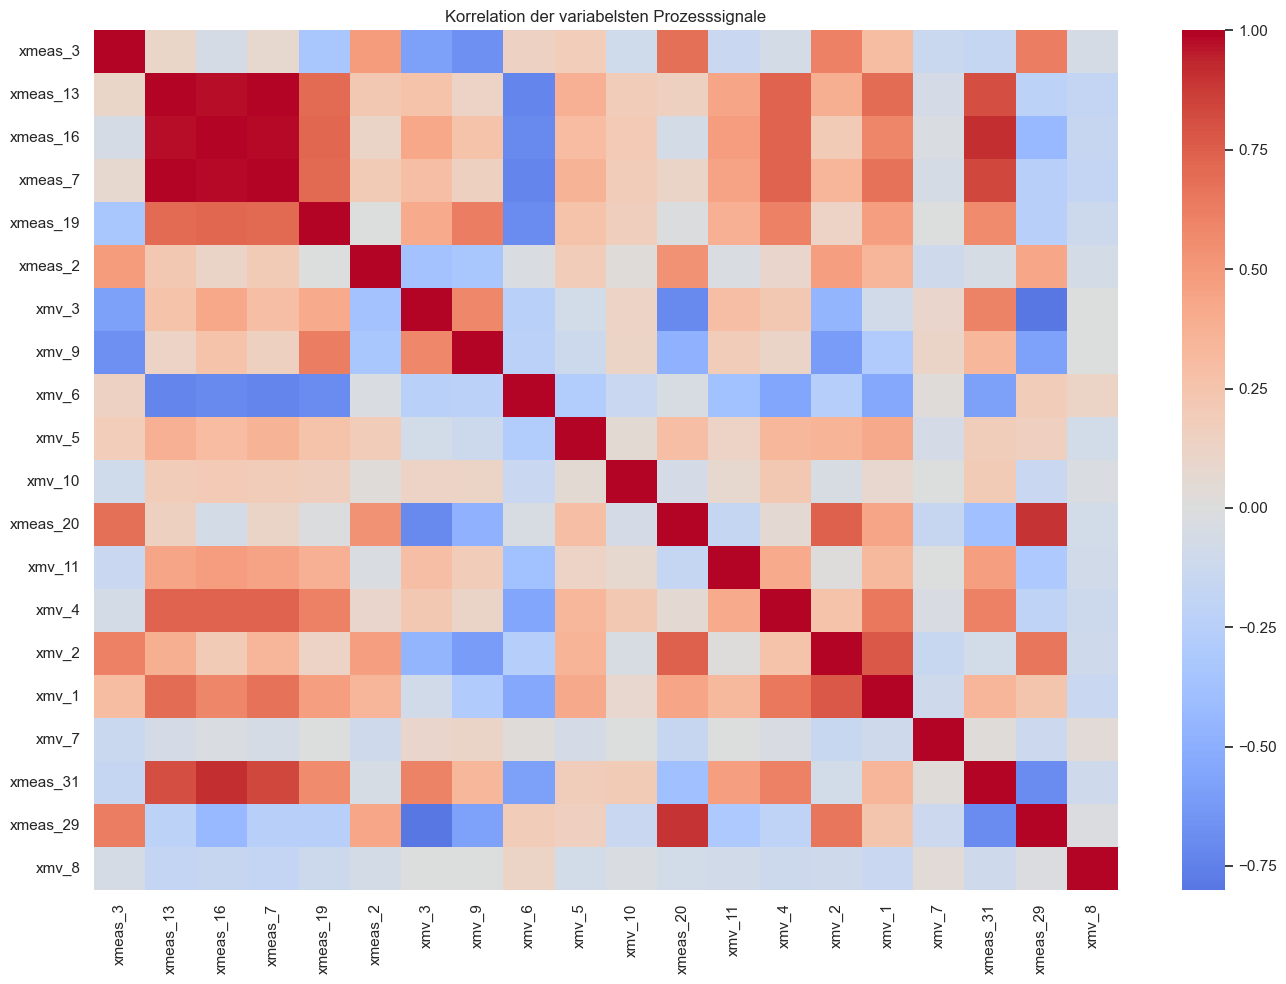

In [6]:
sensor_columns = [column for column in df.columns if column.startswith(("xmeas_", "xmv_"))]
measurement_columns = [column for column in sensor_columns if column.startswith("xmeas_")]
manipulated_columns = [column for column in sensor_columns if column.startswith("xmv_")]

sensor_summary = pd.DataFrame(
    {
        "group": ["Messungen", "Stellgrößen", "Gesamt"],
        "columns": [len(measurement_columns), len(manipulated_columns), len(sensor_columns)],
    }
)
display(sensor_summary)

non_constant_columns = df[sensor_columns].var(numeric_only=True).sort_values(ascending=False)
selected_columns = non_constant_columns.head(20).index.tolist()

plt.figure(figsize=(14, 10))
corr = df[selected_columns].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=False)
plt.title("Korrelation der variabelsten Prozesssignale")
plt.tight_layout()
plt.show()

## 4. Korrelation der Prozesssignale

Diese Heatmap zeigt nur die 20 variabelsten Mess- und Stellgrößen. Die Werte sind paarweise Korrelationen zwischen `-1` und `1`:
- `1` bedeutet, dass zwei Signale stark gemeinsam steigen oder fallen.
- `-1` bedeutet, dass ein Signal steigt, während das andere fällt.
- Werte nahe `0` bedeuten, dass kein klarer linearer Zusammenhang sichtbar ist.

Warum nur diese Spalten?
- Sehr konstante Signale tragen kaum Information zur Anomalieerkennung bei.
- Weniger relevante oder fast unveränderte Spalten würden die Heatmap unleserlich machen.
- Für AutoML ist es oft hilfreicher, erst die dynamischen Prozesssignale zu betrachten.

In [7]:
run_column = next((column for column in ("simulationrun", "run_id", "simulation_run") if column in df.columns), None)
time_column = next((column for column in ("sample", "timestamp", "time") if column in df.columns), None)
plot_columns = [column for column in ("xmeas_7", "xmeas_8", "xmeas_9", "xmv_1", "xmv_10") if column in df.columns]
local_label_column = next((column for column in ("faultnumber", "fault_id", "label") if column in df.columns), None)

if run_column is None or time_column is None or not plot_columns:
    print("Für den Zeitverlauf werden Run-, Zeit- und Sensorkolonnen benötigt. Bitte prüfe das Schema des Parquet-Exports.")
else:
    selected_run = df[run_column].iloc[0]
    run_frame = df[df[run_column] == selected_run].sort_values(time_column)

    title_suffix = f"Run {selected_run}"
    if local_label_column is not None and not run_frame[local_label_column].dropna().empty:
        run_label = run_frame[local_label_column].dropna().iloc[0]
        title_suffix = f"Run {selected_run} - Fault {run_label}"

    fig = px.line(
        run_frame,
        x=time_column,
        y=plot_columns,
        title=f"Ausgewählte Prozesssignale über die Zeit ({title_suffix})",
        labels={time_column: time_column, "value": "value", "variable": "signal"},
    )
    fig.show()

## 5. Zeitverlauf einzelner Signale

Diese Visualisierung zeigt beispielhaft einige Prozesssignale über die Zeit für einen einzelnen Run. So erkennst du typische Muster wie:
- langsame Drift
- plötzliche Sprünge
- schrittweise Änderungen
- Reaktionen zwischen Messgrößen und Stellgrößen

Das ist besonders wichtig für Anomalieerkennung, weil viele Fehler nicht in einem Einzelwert liegen, sondern im zeitlichen Verhalten des Prozesses.

In [8]:
local_label_column = next((column for column in ("faultnumber", "fault_id", "label") if column in df.columns), None)
local_sensor_columns = [column for column in df.columns if column.startswith(("xmeas_", "xmv_"))]
local_selected_columns = (
    df[local_sensor_columns].var(numeric_only=True).sort_values(ascending=False).head(20).index.tolist()
    if local_sensor_columns
    else []
)

if not local_sensor_columns:
    print("Keine Sensor-Spalten für PCA gefunden.")
else:
    pca_columns = local_selected_columns if local_selected_columns else local_sensor_columns[:20]
    pca_input = df[pca_columns].dropna()

    if pca_input.empty:
        print("Zu viele fehlende Werte für die PCA-Projektion.")
    else:
        sample_size = min(len(pca_input), 5000)
        pca_input = pca_input.sample(sample_size, random_state=42) if len(pca_input) > sample_size else pca_input

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(pca_input)

        pca = PCA(n_components=2)
        pca_results = pca.fit_transform(scaled_data)

        pca_df = pd.DataFrame(data=pca_results, columns=["PC1", "PC2"], index=pca_input.index)
        if local_label_column is not None and local_label_column in df.columns:
            pca_df[local_label_column] = df.loc[pca_df.index, local_label_column].values

        fig = px.scatter(
            pca_df,
            x="PC1",
            y="PC2",
            color=local_label_column if local_label_column is not None and local_label_column in pca_df.columns else None,
            title="PCA-Projektion der Prozesssignale",
            opacity=0.6,
        )
        fig.show()

## 6. PCA-Projektion

PCA steht für Principal Component Analysis. Das Verfahren reduziert viele zusammenhängende numerische Merkmale auf wenige neue Achsen, die sogenannten Hauptkomponenten. Diese Komponenten sind so gewählt, dass sie möglichst viel von der Varianz der Originaldaten erklären.

Warum ist das hier nützlich?

- Der Tennessee Eastman Datensatz hat viele stark korrelierte Prozesssignale.
- PCA komprimiert diese Signale auf zwei Dimensionen, damit man die Grundstruktur schneller sieht.
- Wenn Fault-Free- und Faulty-Zustände in der Projektion getrennte Bereiche bilden, ist das ein Hinweis darauf, dass die Daten für Anomalieerkennung eine brauchbare Struktur enthalten.

Wie wird PCA im Notebook verwendet?

- Zuerst werden nur die Prozessspalten `xmeas_` und `xmv_` betrachtet.
- Dann werden die 20 variabelsten Signale ausgewählt, damit fast konstante Spalten die Projektion nicht dominieren.
- Vor der PCA werden die Daten mit `StandardScaler` standardisiert, weil PCA skalenabhängig ist.
- Danach werden die Daten auf zwei Komponenten projiziert und als Scatterplot dargestellt.
- Falls eine Fault-Spalte vorhanden ist, werden die Punkte nach Fault-Klasse eingefärbt.

So liest du die Grafik:

- getrennte Cluster sprechen für unterscheidbare Betriebszustände
- starke Überlappung deutet darauf hin, dass die Fault-Klassen im Rohraum schwer zu trennen sind
- Ausreißer können auf seltene Prozesszustände oder Fehler hinweisen

PCA ist damit kein Vorhersagemodell, sondern ein Diagnosewerkzeug, um die Struktur der Daten und mögliche Trennbarkeit zu prüfen.